# w12-2. Optuna — grid search보다 똑똑한 hyperparameter 탐색

**오늘 할 일**
1. 왜 grid search가 비효율적인지 이해
2. **Optuna**로 XGBoost hyperparameter 자동 탐색 (worked example)
3. ✏️ 같은 방식으로 **Random Forest**에도 Optuna 적용

**데이터**: `skin_irritation_2Ddesc.csv` (지난 시간과 동일)

## 🚨 한 줄 요약
지난 시간 우리가 짠 3중 for문(XGBoost 27조합) → **Optuna 5줄**로 줄이고, 더 좋은 hyperparameter도 자동으로 찾음.

## 설치

pip install optuna --quiet (Colab/Jupyter에서 **한 번만** 실행하면 됨. 이미 깔려 있으면 생략.)

In [4]:
pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 78.0 MB/s  0:00:00

   ------ --------------------------------- 1/6 [greenlet]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------------- ------------- 4/6 [alembic]
   --------------------------------- ------ 5/6 [optuna]
   --------------------------------- ------ 5/6 [optuna]
   --------------------------------- ------ 5/6 [optuna]
   ---------------------------------------- 6/6 [optuna]

Note: you may need to restart the kernel to use updated packages.


---
# Part A. 데이터 준비 (셀 그대로 실행)

지난 시간 흐름 그대로. NaN 제거 → 저분산 제거 → SelectKBest로 10개.

In [5]:
import pandas as pd
import warnings
from sklearn.feature_selection import SelectKBest, f_classif

warnings.filterwarnings('ignore')

# 데이터 불러오기
df = pd.read_csv('skin_irritation_2Ddesc.csv')
y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

# NaN 열 제거 + 저분산 열 제거 (매번 이렇게 제거하는 식으로 하고 있지만, 사실 이것까지 처리해서 파일로 저장해놓는게 훨씬 효율적. 귀찮아서 업데이트 안 하긴 했음.)
X = X.dropna(axis=1)
X = X.loc[:, X.std() >= 0.01]

# 상위 10개 descriptor 선택
selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)
cols = X.columns[selector.get_support()]
X_sel = X[cols]

print('X_sel shape:', X_sel.shape)
print('y 분포:')
print(y.value_counts())

X_sel shape: (39, 10)
y 분포:
label
0    26
1    13
Name: count, dtype: int64


---
# Part B. Optuna 개념 — grid vs Optuna

## 🤔 지난 시간 XGBoost grid search를 다시 떠올려 봐

```python
n_estimators   = [50, 100, 200]
max_depths     = [3, 5, 7]
learning_rates = [0.05, 0.1, 0.3]

for n in n_estimators:
    for d in max_depths:
        for lr in learning_rates:
            ...  # 총 3 × 3 × 3 = 27조합
```

문제점 3가지:
1. **조합 폭발** — hyperparameter가 5개면 5중 for문, 너무 많은 조합
2. **격자 밖 못 봄** — `n_estimators=150`이 더 좋아도 grid엔 없으니 모름
3. **별로인 조합도 끝까지** — 시간 낭비

## 🚀 Optuna는 어떻게 다른가

Optuna는 **이전 시도의 결과를 보고 다음 시도를 똑똑하게 결정**해. 좋은 영역은 더 집중 탐색, 별로인 영역은 빨리 포기.

```mermaid
graph LR
    G["🟦 Grid Search<br/>모든 격자점 다 시도<br/>(n=50, lr=0.05)<br/>(n=50, lr=0.1)<br/>(n=50, lr=0.3)<br/>(n=100, lr=0.05)<br/>..."] --> Slow["📉 시간 ↑<br/>최적 못 찾을 수도"]
    O["🟩 Optuna<br/>이전 결과 보고<br/>다음 시도 결정<br/>(베이지안 최적화)"] --> Fast["📈 시간 ↓<br/>더 좋은 값 자주 찾음"]
```

| 항목 | Grid Search | Optuna |
|---|---|---|
| 탐색 방식 | 격자점 전부 | 이전 결과 학습 |
| hyperparameter 5개 | 5중 for문 | 함수 1개 |
| 연속값 (예: lr=0.07) | 격자에 없으면 못 봄 | 자유롭게 시도 가능 |
| 조기 종료 | 없음 | 별로면 빨리 멈춤 |

## B-2. Optuna 기본 패턴 — 3단계

Optuna 사용은 항상 똑같이 **3단계**.

```python
import optuna

# 1️⃣ 한 번의 시도(trial)에서 무엇을 할지 정의하는 함수
def objective(trial):
    # 이번 trial에서 쓸 hyperparameter 제안
    n = trial.suggest_int('n_estimators', 50, 300)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    # 모델 학습 + 평가
    model = XGBClassifier(n_estimators=n, learning_rate=lr, ...)
    score = cross_val_score(model, X, y, cv=5).mean()

    # 점수 반환 (Optuna는 이걸 최대화하려고 함)
    return score

# 2️⃣ study 생성 (direction='maximize' → 점수 최대화)
study = optuna.create_study(direction='maximize')

# 3️⃣ 시도 횟수 정하고 실행
study.optimize(objective, n_trials=50)
```

### suggest_* 함수 핵심 3개

| 함수 | 의미 | 예 |
|---|---|---|
| `trial.suggest_int(이름, 최소, 최대)` | 정수 범위 | `n_estimators`: 50~300 |
| `trial.suggest_float(이름, 최소, 최대)` | 실수 범위 | `learning_rate`: 0.01~0.3 |
| `trial.suggest_categorical(이름, 후보)` | 후보 중 선택 | `kernel`: ['linear','rbf','poly'] |

> 💡 `log=True` 옵션: `learning_rate`처럼 0.01 ~ 0.3 범위에서는 0.01~0.1을 더 촘촘히, 0.1~0.3은 듬성하게 시도. 보통 `learning_rate`엔 `log=True` 권장.

---
# Part C. XGBoost에 Optuna 적용 — worked example

지난 시간 우리가 3중 for문으로 한 작업을 Optuna로 다시 해 보자.

## C-1. objective 함수 작성

`trial`이 들어오면 hyperparameter를 제안하고, CV5 점수를 돌려주는 함수.

In [6]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Optuna 로그 줄이기
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 이번 trial에서 쓸 hyperparameter 제안
    n = trial.suggest_int('n_estimators', 50, 300)
    d = trial.suggest_int('max_depth', 2, 8)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    # 모델 생성
    model = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=lr, random_state=0)

    # 5-fold CV 점수
    score = cross_val_score(model, X_sel, y, cv=5).mean()
    return score

## C-2. study 생성 + 실행

`direction='maximize'` — CV 점수를 **최대화**하라는 뜻. (loss라면 `'minimize'`)

> 💡 `n_trials=50` 몇 번이 적당할까? (hyperparameter가 늘어날수록, search해야 하는 값의 range가 늘어날수록 증가, n_trials를 늘려보면서 더 좋은 결과가 나오는지 확인. 200번 이상을 하기도 함.)

In [7]:
# study 만들기 (점수를 '최대화'하는 방향으로)
study = optuna.create_study(direction='maximize')

# 50번 시도
study.optimize(objective, n_trials=50)

print('완료!')
print('최고 CV 점수       :', round(study.best_value, 3))
print('최적 hyperparameter:', study.best_params)

완료!
최고 CV 점수       : 0.793
최적 hyperparameter: {'n_estimators': 248, 'max_depth': 7, 'learning_rate': 0.13400635744653344}


## C-3. 결과 시각화

Optuna는 그래프 도구를 내장하고 있음.
- **plot_optimization_history**: trial별 점수 변화. 점점 올라가면 잘 작동 중.
- **plot_param_importances**: 어떤 hyperparameter가 점수에 영향을 가장 많이 줬는지.

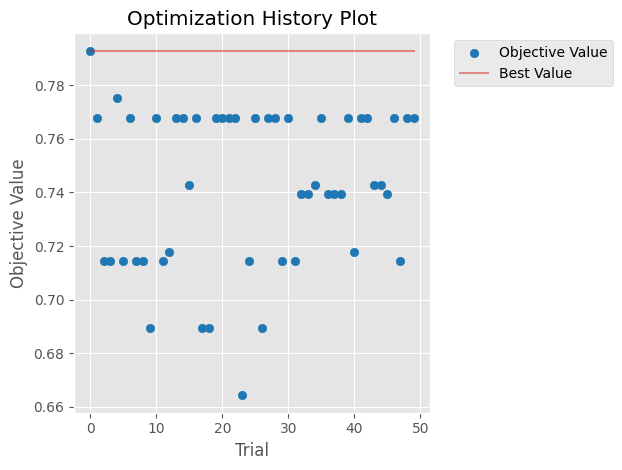

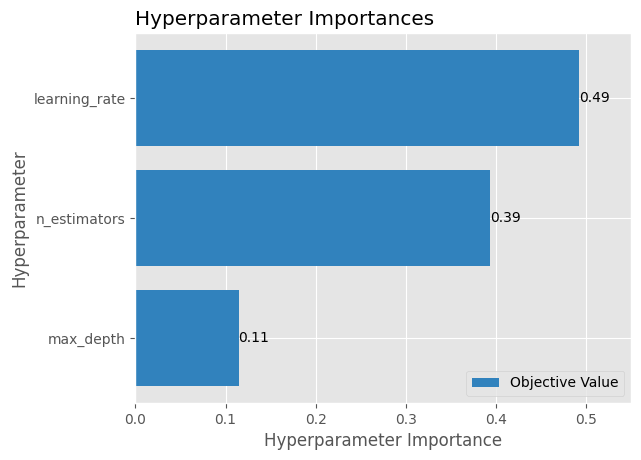

In [8]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
import matplotlib.pyplot as plt

# trial별 점수 변화
plot_optimization_history(study)
plt.show()

# hyperparameter 중요도
plot_param_importances(study)
plt.show()

## C-4. 최적 모델로 최종 학습

`study.best_params`는 dict이라 `**`로 바로 unpack해서 모델에 넘길 수 있음.

> 💡 지난 시간 grid search의 XGB 베스트와 비교해 봐. Optuna가 더 좋은 점수를 찾았는지?

In [9]:
# 최적 hyperparameter로 모델 다시 만들기
best_xgb = XGBClassifier(**study.best_params, random_state=0)
best_xgb.fit(X_sel, y)

print('train 정확도:', round(best_xgb.score(X_sel, y), 3))
print('CV5 점수    :', round(cross_val_score(best_xgb, X_sel, y, cv=5).mean(), 3))

train 정확도: 0.974
CV5 점수    : 0.793


---
# Part D. ✏️ Quiz — Random Forest에 Optuna 적용

XGBoost에서 한 패턴을 그대로 Random Forest에 옮기기.

**힌트**
- `from sklearn.ensemble import RandomForestClassifier`
- 탐색할 hyperparameter:
  - `n_estimators`: 50 ~ 500 (정수)
  - `max_depth`: 2 ~ 20 (정수)
  - `min_samples_split`: 2 ~ 10 (정수)
- C-1 패턴 그대로 `objective_rf` 함수 작성
- `optuna.create_study(direction='maximize')` → `optimize(..., n_trials=30)`

In [17]:
from sklearn.ensemble import RandomForestClassifier
import optuna

# ✏️ Quiz 1: objective 함수 작성
def objective_rf(trial):
    # n_estimators: 50 ~ 500 정수
    n = trial.suggest_int('n_estimators', 50, 500)
    # max_depth: 2 ~ 20 정수
    d = trial.suggest_int('max_depth', 2, 20)
    # min_samples_split: 2 ~ 10 정수
    s = trial.suggest_int('min_samples_split', 2, 10)
    # RandomForestClassifier 생성 (random_state=0)
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=d,
        min_samples_split=s
    )

    # 5-fold CV 점수 반환
    score = cross_val_score(model, X_sel, y, cv=5).mean()

    return score

# ✏️ Quiz 2: study 생성 (direction='maximize') + 30번 시도
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=30)

# ✏️ Quiz 3: 결과 출력 (best_value, best_params)
print('RF 최고 CV 점수       :', round(study_rf.best_value, 3))
print('RF 최적 hyperparameter:', study_rf.best_params)

RF 최고 CV 점수       : 0.875
RF 최적 hyperparameter: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2}


## ✏️ Quiz 4 — XGBoost와 RF 결과 비교

위에서 찾은 XGBoost 최고 점수와 RF 최고 점수를 한 막대 그래프로 비교.

**힌트**
- 점수 2개: `study.best_value` (XGB), `study_rf.best_value` (RF)
- `plt.bar(['XGB', 'RF'], [점수1, 점수2])`

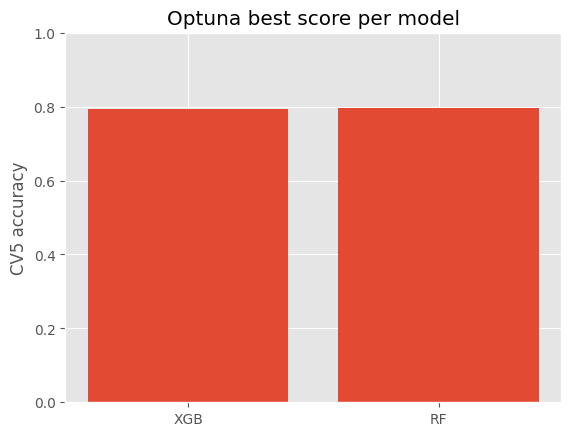

In [11]:
import matplotlib.pyplot as plt

# ✏️ Quiz 4: XGB vs RF best CV 점수 막대 그래프
# scores = [study.best_value, study_rf.best_value]
scores = [study.best_value, study_rf.best_value]
# plt.bar(['XGB', 'RF'], scores)
plt.bar(['XGB', 'RF'], scores)
# plt.ylim(0, 1)
plt.ylim(0, 1)
# plt.ylabel('CV5 accuracy')
plt.ylabel('CV5 accuracy')
# plt.title('Optuna best score per model')
plt.title('Optuna best score per model')
# plt.show()
plt.show()

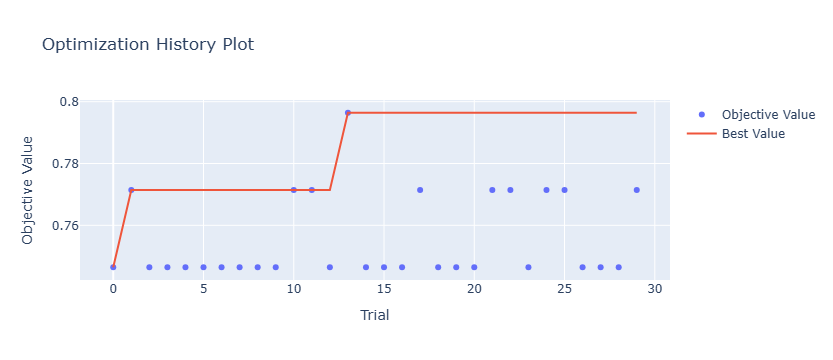

In [15]:
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_optimization_history(study_rf)

---
# Part E. 다른 metric으로 최적화하기

지금까지 우리가 최대화한 것은 **accuracy** (맞춘 비율). 그런데 우리 데이터는 **불균형**:
- label 0 (자극 없음): **26개**
- label 1 (자극 있음): **13개**

## 🚨 accuracy의 함정

모델이 **모든 분자를 label=0으로만 예측**한다면?

→ accuracy = 26 / 39 = **0.667** (꽤 높아 보임!)
→ 하지만 자극 있는 분자(label=1)는 **단 하나도 못 맞춤** = 실제로는 쓸모없는 모델

**불균형 데이터에서는 accuracy 외에 다른 metric도 함께 봐야 함.**

## 주요 metric 정리

| metric | 한 줄 설명 | sklearn 이름 |
|---|---|---|
| accuracy | 맞춘 비율 | `'accuracy'` |
| sensitivity (recall) | label=1 중 맞춘 비율 (자극 있는 것 잘 찾음) | `'recall'` |
| specificity | label=0 중 맞춘 비율 (자극 없는 것 잘 찾음) | (직접 만듦) |
| **MCC** | TP/TN/FP/FN 모두 고려, 불균형에 강함. -1 ~ +1 | `'matthews_corrcoef'` |
| balanced_accuracy | (sensitivity + specificity) / 2 | `'balanced_accuracy'` |
| F1 | precision과 recall의 조화평균 | `'f1'` |

## E-1. MCC를 objective로 — `scoring` 인자 한 줄만 바꾸면 됨

`cross_val_score(..., scoring='matthews_corrcoef')` — sklearn metric을 **문자열로 지정**.

다른 metric도 같은 방식: `'f1'`, `'balanced_accuracy'`, `'roc_auc'` 등.

In [12]:
# objective 함수에서 cross_val_score의 scoring만 변경
def objective_mcc(trial):
    n = trial.suggest_int('n_estimators', 50, 300)
    d = trial.suggest_int('max_depth', 2, 8)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    model = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=lr, random_state=0)

    # ⭐ scoring만 변경: accuracy → MCC
    score = cross_val_score(model, X_sel, y, cv=5, scoring='matthews_corrcoef').mean()
    return score

study_mcc = optuna.create_study(direction='maximize')
study_mcc.optimize(objective_mcc, n_trials=50)

print('최고 MCC          :', round(study_mcc.best_value, 3))
print('MCC 기준 best 파라미터:', study_mcc.best_params)
print()
print('💡 accuracy 기준 best와 비교해 봐 — 다른 hyperparameter가 best로 나올 수도 있음.')

최고 MCC          : 0.431
MCC 기준 best 파라미터: {'n_estimators': 138, 'max_depth': 6, 'learning_rate': 0.07687779072568263}

💡 accuracy 기준 best와 비교해 봐 — 다른 hyperparameter가 best로 나올 수도 있음.


## E-2. 다중 목표 (multi-objective) — sensitivity와 specificity 둘 다

MCC는 두 지표를 **하나의 숫자**로 합친 것. 그런데 가끔은 **"sensitivity도 높고, specificity도 높고"** 둘을 따로 보고 싶을 때가 있어 (예: 의약품 후보 → 자극 있는 것 놓치면 안 됨 + 안전한 것을 함부로 버려도 안 됨).

→ Optuna의 **multi-objective** 모드.
- `create_study(directions=['maximize', 'maximize'])` — 점수 **2개**를 동시에 최대화
- objective는 **tuple로 점수 2개 return**
- 결과는 단일 best가 아니라 **Pareto front** — "한쪽을 더 좋게 하려면 다른 쪽을 포기해야 하는" 균형점들

> 💡 `specificity`는 sklearn에 직접 이름이 없음 → `make_scorer(recall_score, pos_label=0)`로 만듦. "label=0을 양성으로 보고 recall 계산" = specificity.

In [13]:
from sklearn.metrics import make_scorer, recall_score

# specificity = label=0의 recall (label=0을 양성으로 본 recall)
spec_scorer = make_scorer(recall_score, pos_label=0)

def objective_multi(trial):
    n = trial.suggest_int('n_estimators', 50, 300)
    d = trial.suggest_int('max_depth', 2, 8)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    model = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=lr, random_state=0)

    # 점수 두 개 계산
    sens = cross_val_score(model, X_sel, y, cv=5, scoring='recall').mean()
    spec = cross_val_score(model, X_sel, y, cv=5, scoring=spec_scorer).mean()

    # ⭐ tuple로 두 점수 return
    return sens, spec

# directions에 'maximize' 두 개
study_multi = optuna.create_study(directions=['maximize', 'maximize'])
study_multi.optimize(objective_multi, n_trials=50)

# Pareto front: 한쪽을 더 좋게 하려면 다른 쪽을 포기해야 하는 trial들
print(f'Pareto 최적 trial: {len(study_multi.best_trials)}개')
print()
print(f'{"sens":>6}  {"spec":>6}  파라미터')
for t in study_multi.best_trials:
    print(f'{t.values[0]:>6.3f}  {t.values[1]:>6.3f}  {t.params}')

Pareto 최적 trial: 25개

  sens    spec  파라미터
 0.500   0.893  {'n_estimators': 295, 'max_depth': 7, 'learning_rate': 0.09023089752408639}
 0.500   0.893  {'n_estimators': 131, 'max_depth': 8, 'learning_rate': 0.08780372703825975}
 0.500   0.893  {'n_estimators': 217, 'max_depth': 5, 'learning_rate': 0.09429892765967651}
 0.500   0.893  {'n_estimators': 93, 'max_depth': 5, 'learning_rate': 0.1589496910760213}
 0.500   0.893  {'n_estimators': 166, 'max_depth': 7, 'learning_rate': 0.18133555150681083}
 0.500   0.893  {'n_estimators': 156, 'max_depth': 3, 'learning_rate': 0.05053067990250156}
 0.500   0.893  {'n_estimators': 257, 'max_depth': 4, 'learning_rate': 0.04858445191478917}
 0.500   0.893  {'n_estimators': 231, 'max_depth': 6, 'learning_rate': 0.09188727974130075}
 0.500   0.893  {'n_estimators': 118, 'max_depth': 5, 'learning_rate': 0.254438733768932}
 0.500   0.893  {'n_estimators': 252, 'max_depth': 5, 'learning_rate': 0.1808673046221626}
 0.500   0.893  {'n_estimators': 131, 'max

## ✏️ Quiz — `balanced_accuracy` 또는 `f1`으로 다시 최적화

E-1 패턴 그대로, `scoring=` 만 바꿔서 다른 metric을 최대화.

**힌트**
- `scoring='balanced_accuracy'` 또는 `'f1'`
- `study_bal.best_value`를 accuracy 기준(C-2 결과)과 비교
- 같은 hyperparameter가 best로 나오나? 다르게 나오나?

In [14]:
# ✏️ Quiz: scoring을 'balanced_accuracy' 또는 'f1'로 바꿔서 study 실행
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import optuna

def objective_bal(trial):
    # E-1 코드 그대로, scoring만 변경
    n = trial.suggest_int('n_estimators', 50, 300)
    d = trial.suggest_int('max_depth', 2, 8)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    model = XGBClassifier(
        n_estimators=n,
        max_depth=d,
        learning_rate=lr,
        random_state=0
    )
    score = cross_val_score(
        model,
        X_sel,
        y,
        cv=5,
        scoring='balanced_accuracy'   # ⭐ 여기만 변경 (f1로 바꿔도 됨)
    ).mean()

    return score
    
# study 생성 + 50번 실행 (study_bal)
study_bal = optuna.create_study(direction='maximize')
study_bal.optimize(objective_bal, n_trials=50)

# best_value 출력 + C-2 accuracy 결과와 비교
print('Balanced Accuracy best value:', round(study_bal.best_value, 3))

print('Accuracy 기준 (C-2): 0.775')

print('Best params:', study_bal.best_params)

Balanced Accuracy best value: 0.697
Accuracy 기준 (C-2): 0.775
Best params: {'n_estimators': 152, 'max_depth': 3, 'learning_rate': 0.08607437264187456}


---
## 정리 — grid search vs Optuna

**오늘 배운 것**
1. Optuna는 hyperparameter를 **이전 시도 결과를 보고 똑똑하게 제안**
2. 3단계 패턴: `objective(trial)` → `create_study` → `optimize`
3. `suggest_int / suggest_float / suggest_categorical`로 탐색 범위 지정
4. `cross_val_score(..., scoring=...)`로 **다른 metric도 최적화 가능** (accuracy / MCC / F1 / balanced_accuracy)
5. **다중 목표**: `directions=['maximize','maximize']` + tuple return → **Pareto front**

**Grid vs Optuna 한 줄 비교**

| | Grid (3중 for문) | Optuna |
|---|---|---|
| 코드 길이 | 12~15줄 | 5~7줄 |
| 시도 횟수 (XGB) | 27조합 고정 | n_trials로 자유 |
| 새 hyperparameter 추가 | for문 한 줄 더 (조합 ×N 폭발) | suggest 한 줄 더 |
| 연속값 탐색 | 격자에만 | 범위 안 어디든 |
| metric 변경 | 함수 다시 짜야 함 | `scoring=` 한 줄 |
| 다중 목표 | 직접 구현 | `directions=[...]` 한 줄 |

**시험 포인트**
- `direction='maximize'` vs `'minimize'` — 점수를 올릴 건지 내릴 건지
- `trial.suggest_*` 3종류 외우기
- objective 함수는 **점수 하나 (또는 다중 목표일 때 tuple)를 return**
- **불균형 데이터에서는 accuracy 함정 주의** → MCC / balanced_accuracy / F1 같이 보기

> ✅ 추가 학습: 지난 시간 SVM `(C, kernel)` grid search도 Optuna로 다시 짜 보기. `suggest_categorical`이 필요함.